# Energy Balance - Empirical
A notebook to check both the atmospheric and surface energy balance to ensure that they match the actual energy balance

In [1]:
import sys
import os
import xarray as xr
import inspect

from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff, get_heat_cap_lambda_eff2, get_heat_cap_lambda_eff3

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import numpy as np
import matplotlib.pyplot as plt
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
exp_dir = f'tau_sweep/aquaplanet/depth=1/'
exp_name = 'k=1'
# exp_dir = f'thesis_season/depth=5/'  # constrained no WISHE and const RH
# exp_name = 'sw_wind_moist'
lat_use = 40
ds_base = utils.load_ds(exp_name, exp_dir, lat_min=lat_use - 1, lat_max=lat_use + 1,
                        first_month_file=25 if 'tau_sweep' in exp_dir else 121,
                        verbose=True).isel(lat=0)

Computing column temp, sphum, and rh: 100%|██████████| 3/3 [00:17<00:00,  5.79s/it]


In [3]:
ds = utils.process_ds(ds_base)

In [4]:
feedback_params = {key: utils.get_empirical_params(ds, include_phase_lh=key == 'phase') for key in
                   ['no_phase', 'phase']}

## Atmospheric Energy Budget
This is closed by definition with advection, but for single column it serves as a sanity check.

In [5]:
def remove_mean(var, mean_dim='time'):
    return var - var.mean(dim=mean_dim)

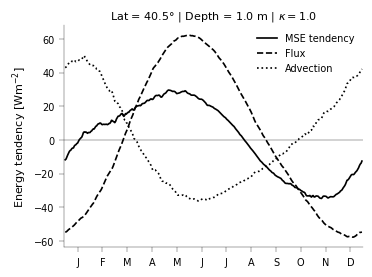

In [6]:
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'] * 0.7)
ax.plot(ds.time, remove_mean(ds['mse_tend_atmos']), color='k', label='MSE tendency')
ax.plot(ds.time, remove_mean(ds['flux_atmos']), color='k', label='Flux', linestyle='--')
if 'column' not in exp_dir:
    ax.plot(ds.time, remove_mean(ds['adv_atmos']), color='k', label='Advection', linestyle=':')
else:
    print(f"Max error = {np.abs(ds['adv_atmos']).max():.2f} W/m2")
update_linewidth(fig)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_ylabel('Energy tendency [Wm$^{-2}$]')
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.legend()
ax.set_title(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth:.1f} m | $\kappa = {ds.odp:.1f}$', y=0.99)
plt.show()

### Empirical approximation
Below I compare the empirical approximation for each of the components of the atmospheric energy budget. We see that the approximate empircally fitted computation is not great for the fluxes.

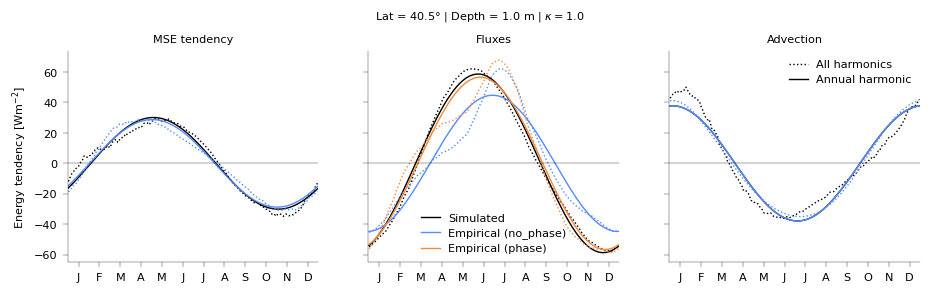

In [7]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 2)

# MSE tendency - simulated
ax[0].set_title('MSE tendency')
ax[0].plot(ds.time, ds['mse_tend_atmos'], color='k', linestyle=':')
var = get_fourier_fit_xr(ds.time, ds['mse_tend_atmos'], n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds.time, var, color='k', label='Simulated')

# MSE tendency - empirical
var = utils.get_approx_mse_tend(ds.temp_atm, feedback_params['no_phase']['coef_amp_col'],
                                feedback_params['no_phase']['coef_phase_col'],
                                feedback_params['no_phase']['mu'], ds['p_integ_calc'].mean(dim='time'), ds.time)
ax[0].plot(ds.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds.time, var, color='C0', label='Empirical')

# fluxes - simulated
ax[1].set_title('Fluxes')
var = ds['flux_atmos'] - ds['flux_atmos'].mean(dim='time')
ax[1].plot(ds.time, var, color='k', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[1].plot(ds.time, var, color='k', label='Simulated')

# fluxes - empirical
for i, key in enumerate(feedback_params):
    var = utils.get_approx_flux_atmos(ds.temp_atm, ds.temp_surf, ds.swdn_toa, ds.sw_abs,
                                      feedback_params[key]['lambda_const'],
                                      feedback_params[key]['lambda_a'], feedback_params[key]['B'],
                                      feedback_params[key]['lambda_lw'],
                                      feedback_params[key]['coef_phase_olr'],
                                      feedback_params[key]['coef_phase_a'] if key == 'phase' else None)
    ax[1].plot(ds.time, var, color=f'C{i}', linestyle=':')
    var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
    ax[1].plot(ds.time, var, color=f'C{i}', label=f'Empirical ({key})')

# advection - simulated
ax[2].set_title('Advection')
var = ds['adv_atmos'] - ds['adv_atmos'].mean(dim='time')
ax[2].plot(ds.time, var, color='k', linestyle=':', label='All harmonics')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[2].plot(ds.time, var, color='k', label='Annual harmonic')

# advection - empirical
var = utils.get_approx_adv_atmos(ds.temp_atm, feedback_params['no_phase']['lambda_adv'],
                                 feedback_params['no_phase']['coef_phase_adv'])
ax[2].plot(ds.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[2].plot(ds.time, var, color='C0')

update_linewidth(fig)
ax[1].legend()
ax[2].legend()
for i, ax_use in enumerate(ax):
    ax_use.axhline(0, color='k', lw=ax_linewidth)
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_ylabel('Energy tendency [Wm$^{-2}$]')
fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth:.1f} m | $\kappa = {ds.odp:.1f}$', y=1.03)
update_fontsize(fig)
plt.show()

## Surface energy budget
Now I repeat the plots but for the surface energy budget.

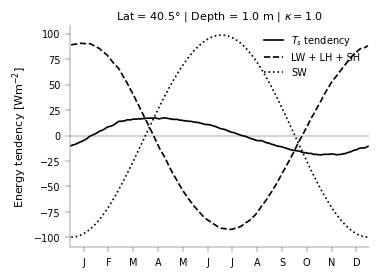

In [8]:
sanity_check = False
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'] * 0.7)
ax.plot(ds.time,
        remove_mean(ds.heat_cap_surf * utils.spline_deriv_periodic_xr(ds.time * utils.day_seconds, ds.temp_surf)),
        color='k', label='$T_s$ tendency')
ax.plot(ds.time, -remove_mean(ds['flux_surf']), color='k', label='LW + LH + SH', linestyle='--')
ax.plot(ds.time, remove_mean(ds.swdn_sfc), color='k', label='SW', linestyle=':')
if sanity_check:
    # Should overlap with the solid black line
    ax.plot(ds.time, remove_mean(ds.swdn_sfc - ds['flux_surf']), color='r', linestyle='-.')
update_linewidth(fig)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_ylabel('Energy tendency [Wm$^{-2}$]')
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.legend()
ax.set_title(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth:.1f} m | $\kappa = {ds.odp:.1f}$', y=0.99)
plt.show()

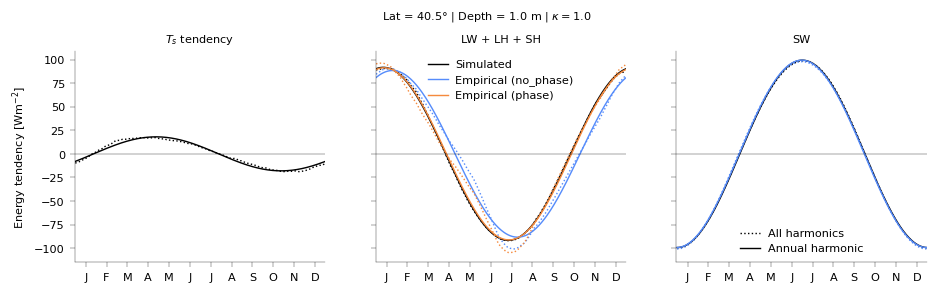

In [9]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 2)

# MSE tendency - simulated (is no empirical version)
ax[0].set_title('$T_s$ tendency')
var = remove_mean(ds.heat_cap_surf * utils.spline_deriv_periodic_xr(ds.time * utils.day_seconds, ds.temp_surf))
ax[0].plot(ds.time, var, color='k', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds.time, var, color='k')

# fluxes - simulated
ax[1].set_title('LW + LH + SH')
var = -remove_mean(ds['flux_surf'])
ax[1].plot(ds.time, var, color='k', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[1].plot(ds.time, var, color='k', label='Simulated')

# fluxes - empirical
for i, key in enumerate(feedback_params):
    var = utils.apply_linear_zero_mean_xr(ds.temp_atm - ds.temp_surf, feedback_params[key]['lambda_const'],
                                          ds.temp_atm, -feedback_params[key]['lambda_a'],
                                          feedback_params[key]['coef_phase_a'] if key == 'phase' else None)
    ax[1].plot(ds.time, var, color=f'C{i}', linestyle=':')
    var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
    ax[1].plot(ds.time, var, color=f'C{i}', label=f'Empirical ({key})')

# advection - simulated
ax[2].set_title('SW')
ax[2].plot(ds.time, remove_mean(ds.swdn_sfc), color='k', linestyle=':', label='All harmonics')
var = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)[0]
ax[2].plot(ds.time, remove_mean(var), color='k', label='Annual harmonic')

# advection - empirical
var = remove_mean((1 - ds.albedo) * (1 - ds.sw_abs) * ds.swdn_toa)
ax[2].plot(ds.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[2].plot(ds.time, var, color='C0')

update_linewidth(fig)
ax[2].legend()
ax[1].legend()
for i, ax_use in enumerate(ax):
    ax_use.axhline(0, color='k', lw=ax_linewidth)
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_ylabel('Energy tendency [Wm$^{-2}$]')
fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth:.1f} m | $\kappa = {ds.odp:.1f}$', y=1.03)
update_fontsize(fig)
plt.show()

### Individual fluxes
To see the issue with the fluxes, I look at each of the individual fluxes in turn.

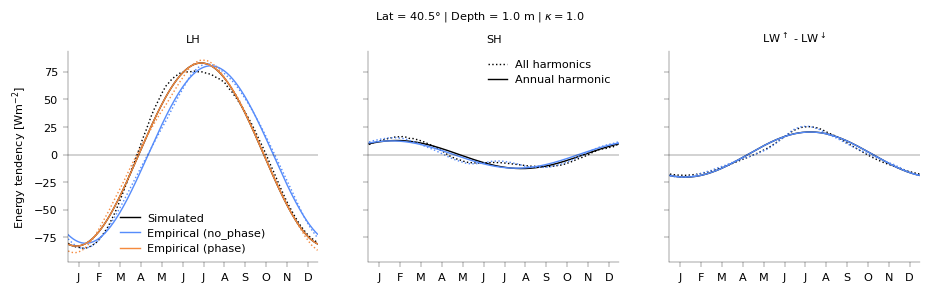

In [10]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 2)

# LH - simulated
ax[0].set_title('LH')
var = remove_mean(ds['flux_lhe'])
ax[0].plot(ds.time, var, color='k', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds.time, var, color='k', label='Simulated')

# LH - empirical
for i, key in enumerate(feedback_params):
    var = utils.apply_linear_zero_mean_xr(ds['temp_surf'] - ds['temp_atm'], feedback_params[key]['lambda_const_lh'],
                                          ds['temp_atm'], feedback_params[key]['lambda_a_lh'],
                                          feedback_params[key]['coef_phase_a_lh'] if key == 'phase' else None)
    ax[0].plot(ds.time, var, color=f'C{i}', linestyle=':')
    var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
    ax[0].plot(ds.time, var, color=f'C{i}', label=f'Empirical ({key})')

# SH - simulated
ax[1].set_title('SH')
var = remove_mean(ds['flux_t'])
ax[1].plot(ds.time, var, color='k', linestyle=':', label='All harmonics')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[1].plot(ds.time, var, color='k', label='Annual harmonic')

# SH - empirical
var = utils.apply_linear_zero_mean_xr(ds['temp_surf'] - ds['temp_atm'], feedback_params['no_phase']['lambda_const_sh'],
                                      ds['temp_atm'], -feedback_params['no_phase']['lambda_a_sh'])
ax[1].plot(ds.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[1].plot(ds.time, var, color='C0')

# LW - simulated
ax[2].set_title('LW$^{\\uparrow}$ - LW$^{\\downarrow}$')
var = remove_mean(ds['lwup_sfc'] - ds['lwdn_sfc'])
ax[2].plot(ds.time, var, color='k', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[2].plot(ds.time, var, color='k')

# LW - empirical
var = utils.apply_linear_zero_mean_xr(ds['temp_surf'] - ds['temp_atm'], feedback_params['no_phase']['lambda_const_lw'],
                                      ds['temp_atm'], feedback_params['no_phase']['lambda_a_lw'])
ax[2].plot(ds.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[2].plot(ds.time, var, color='C0')

update_linewidth(fig)
ax[0].legend()
ax[1].legend()
for i, ax_use in enumerate(ax):
    ax_use.axhline(0, color='k', lw=ax_linewidth)
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_ylabel('Energy tendency [Wm$^{-2}$]')
fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth:.1f} m | $\kappa = {ds.odp:.1f}$', y=1.03)
update_fontsize(fig)
plt.show()

In [11]:
# Sanity check that coef_phase_a obtained correctly so fluxes sum up to be equal
key = 'no_phase'
var = utils.apply_linear_zero_mean_xr(ds.temp_surf - ds.temp_atm, feedback_params[key]['lambda_const'],
                                      ds.temp_atm, feedback_params[key]['lambda_a'],
                                      feedback_params[key]['coef_phase_a'])
var2 = utils.apply_linear_zero_mean_xr(ds['temp_surf'] - ds['temp_atm'], feedback_params[key]['lambda_const_lh'],
                                       ds['temp_atm'], feedback_params[key]['lambda_a_lh'],
                                       feedback_params[key]['coef_phase_a_lh'] if key == 'phase' else None)
var2 += utils.apply_linear_zero_mean_xr(ds['temp_surf'] - ds['temp_atm'],
                                        feedback_params['no_phase']['lambda_const_sh'],
                                        ds['temp_atm'], -feedback_params['no_phase']['lambda_a_sh'])
var2 += utils.apply_linear_zero_mean_xr(ds['temp_surf'] - ds['temp_atm'],
                                        feedback_params['no_phase']['lambda_const_lw'],
                                        ds['temp_atm'], feedback_params['no_phase']['lambda_a_lw'])

xr.testing.assert_allclose(var, var2, atol=1e-1)

### Annual harmonic phase and amplitude
First I compute the effective heat capacity and $\lambda$ using three different methods, then I compare to see if they are equal as a sanity check.


In [12]:
heat_cap_eff_theory = {}
lambda_eff_theory = {}

# first method
arg_names = list(inspect.signature(get_heat_cap_lambda_eff).parameters.keys())
args1 = {key: feedback_params['no_phase'][key] for key in arg_names if key in feedback_params['no_phase']}
for key in ['sh', 'lh']:
    args1[f'lambda_{key}'] = feedback_params['no_phase'][f'lambda_a_{key}']
args1['lambda_lw2'] = feedback_params['no_phase'][f'lambda_a_lw']
args1['lambda_lw1'] = feedback_params['no_phase'][f'lambda_lw']
args1['heat_cap_surf'] = ds.heat_cap_surf
args1['pressure_heat_cap_atmos_calc'] = float(ds.p_integ_calc.mean(dim='time'))
args1['sw_abs'] = float(ds.sw_abs)
args1['albedo'] = ds.albedo

var = get_heat_cap_lambda_eff(**args1)
heat_cap_eff_theory['1'] = var[1]*args1['heat_cap_surf']
lambda_eff_theory['1'] = var[0]*args1['lambda_const']

# second method
arg_names = list(inspect.signature(get_heat_cap_lambda_eff2).parameters.keys())
args2 = {key: args1[key] for key in arg_names if key in args1}
var = get_heat_cap_lambda_eff2(**args2, small_phase=True)
heat_cap_eff_theory['2'] = var[1]
lambda_eff_theory['2'] = var[0]

# second method with advection and no phase approximation
var = get_heat_cap_lambda_eff2(**args2, small_phase=False, lambda_adv=feedback_params['no_phase']['lambda_adv'],
                               coef_phase_adv=feedback_params['no_phase']['coef_phase_adv'])
heat_cap_eff_theory['2_adv'] = var[1]
lambda_eff_theory['2_adv'] = var[0]

# third method - ignore lambda_a phase term as not in other methods
arg_names = list(inspect.signature(get_heat_cap_lambda_eff3).parameters.keys())
args3 = {key: args1[key] for key in arg_names if key in args1}
args3['lambda_a'] = feedback_params['no_phase']['lambda_a'].copy()
args3['lambda_lw'] = feedback_params['no_phase']['lambda_lw'].copy()
var = get_heat_cap_lambda_eff3(**args3, small_phase=True)
heat_cap_eff_theory['3'] = var[1]
lambda_eff_theory['3'] = var[0]

# third method with advection and no phase approximation
var = get_heat_cap_lambda_eff3(**args3, small_phase=False, lambda_adv=feedback_params['no_phase']['lambda_adv'],
                               coef_phase_adv=feedback_params['no_phase']['coef_phase_adv'])
heat_cap_eff_theory['3_adv'] = var[1]
lambda_eff_theory['3_adv'] = var[0]

for var in [heat_cap_eff_theory, lambda_eff_theory]:
    xr.testing.assert_allclose(var["1"], var["2"])
    xr.testing.assert_allclose(var["1"], var["3"])
    xr.testing.assert_allclose(var["2_adv"], var["3_adv"])

# Final method using the lambda_a_phase
# Need phase version for final case - should only be lambda_a_lh and lambda_a
for key in feedback_params['no_phase']:
    if not isinstance(feedback_params['no_phase'][key], xr.DataArray):
        continue
    if not feedback_params['no_phase'][key].equals(feedback_params['phase'][key]):
        print(key)
        if key in args3:
            args3[key] = feedback_params['phase'][key]
var = get_heat_cap_lambda_eff3(**args3, small_phase=False, lambda_adv=feedback_params['no_phase']['lambda_adv'],
                               coef_phase_adv=feedback_params['no_phase']['coef_phase_adv'],
                               coef_phase_a=feedback_params['no_phase']['coef_phase_a'])
heat_cap_eff_theory['final'] = var[1]
lambda_eff_theory['final'] = var[0]

lambda_a_lh
lambda_a


In [19]:
phase_info = {key: {} for key in ['coef_phase', 'coef_amp', 'heat_cap_eff', 'lambda_eff']}
for key in phase_info:
    phase_info[key]['simulated'] = ds[key]
for key in ['heat_cap_eff', 'lambda_eff']:
    var = {'heat_cap_eff': heat_cap_eff_theory, 'lambda_eff': lambda_eff_theory}[key]
    phase_info[key]['no_adv_no_phase'] = var['3']
    phase_info[key]['no_phase'] = var['3_adv']
    phase_info[key]['theory'] = var['final']
for key in ['no_adv_no_phase', 'no_phase', 'theory']:
    phase_info['coef_phase'][key], phase_info['coef_amp'][key] = utils.get_phase_amp(ds.coef_sw_amp, ds.omega, phase_info['heat_cap_eff'][key],
                                                                                     phase_info['lambda_eff'][key])

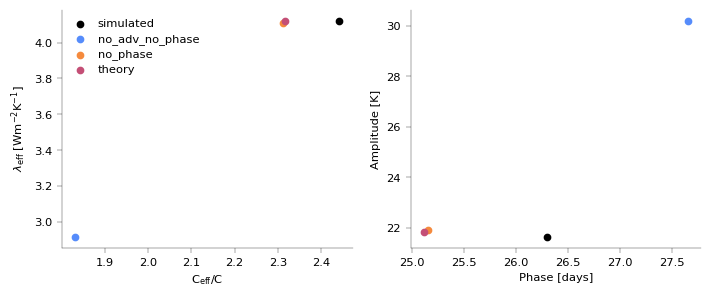

In [26]:
show_phase_time = True
fig, ax = plt.subplots(1, 2)
fig_resize(fig, utils.width['two_col'] * 1.5)

colors_use = ['k', 'C0', 'C1', 'C2']
for i, key in enumerate(phase_info['coef_phase']):
    ax[0].scatter(phase_info['heat_cap_eff'][key]/ds.heat_cap_surf, phase_info['lambda_eff'][key], color=colors_use[i],
                  marker='.', s=50, lw=2, label=key)
    ax[1].scatter(phase_info['coef_phase'][key] / ds.omega / utils.day_seconds if show_phase_time else np.tan(phase_info['coef_phase'][key]),
                  phase_info['coef_amp'][key], color=colors_use[i],
                  marker='.', s=50, lw=2)
ax[0].set_xlabel("C$_{\\text{eff}}/$C")
ax[0].set_ylabel("$\lambda_{\\text{eff}}$ [Wm$^{-2}\\text{K}^{-1}$]")
ax[1].set_xlabel("Phase [days]" if show_phase_time else "$\\tan (\\phi)$")
ax[1].set_ylabel("Amplitude [K]")
ax[0].legend()
# fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth.values:.0f}m | {params_use.capitalize()}')
update_fontsize(fig, 7)
plt.show()